# **DATA SCIENCE CAPSTONE PROJECT – PRCP-1001: Rice Leaf Disease Detection Using Convolutional Neural Networks (CNN)**

**PROJECT TITLE:** Rice Leaf Disease Detection Using Convolutional Neural Networks (CNN)

**TEAM CODE:** PTID-AIE-JUL-26-11142

**PROJECT CODE:** PRCP-1001

**PROJECT TYPE:** Data Science Capstone Project

**DATASET SOURCE:** DataMites Capstone Project Dataset

**DATASET NAME:** Rice Leaf Disease Dataset

**DATASET LINK:** https://d3ilbtxij3aepc.cloudfront.net/projects/CDS-Capstone-Projects/PRCP-1001-RiceLeaf.zip

**SUBMITTED BY:** Sameeksha

---

## **1. Problem Statement & Project Objective**

Rice is one of the most widely cultivated staple food crops in the world, and its yield is significantly affected by leaf diseases. Early and accurate disease identification helps farmers apply the appropriate treatment at the right time, reducing crop loss and improving productivity. However, manual disease detection is time-consuming, subjective, and requires expert knowledge. This project develops an automated Convolutional Neural Network (CNN)-based image classification system to identify rice leaf diseases from leaf images.

### **Project Objectives**

1. **Perform Data Analysis** – Analyze the dataset to understand its structure, class distribution, and image characteristics.

2. **Develop a Classification Model** – Build a CNN model to classify rice leaf images into three disease categories: Bacterial Leaf Blight, Brown Spot, and Leaf Smut.

3. **Apply Data Augmentation** – Use image augmentation techniques to improve model generalization and reduce overfitting.

4. **Compare Multiple Models** – Evaluate the performance of different models and identify the most suitable model for deployment.

5. **Document Challenges and Solutions** – Discuss the challenges encountered during model development and the techniques used to overcome them.

### **About the Dataset**

The dataset consists of 120 rice leaf images, equally distributed across three disease classes (40 images per class):

1. **Bacterial Leaf Blight** – Characterized by long yellow or white streaks along the leaf veins.

2. **Brown Spot** – Identified by small circular or oval brown lesions on the leaf surface.

3. **Leaf Smut** – Characterized by tiny black spots scattered across the leaf.

Since these diseases have distinct visual characteristics such as shape, color, and texture, a Convolutional Neural Network (CNN) is well suited for accurately classifying them from leaf images.


## **2. Import Python Libraries**

The first step in the project is to import the required Python libraries. These libraries provide the functionality needed for data handling, image preprocessing, visualization, deep learning, and model evaluation.

Libraries such as os, shutil, and zipfile are used for file and folder management. NumPy and Pandas are used for numerical computations and data manipulation, while OpenCV (cv2) and PIL are used for image processing. Matplotlib and Seaborn are used to visualize images and model performance.

TensorFlow and Keras are used to build and train the CNN model, while ImageDataGenerator performs image preprocessing and data augmentation. EarlyStopping and ModelCheckpoint help optimize the training process, and classification_report and confusion_matrix are used to evaluate model performance. A fixed SEED = 42 is used to ensure consistent and reproducible results.


In [1]:
import os
import shutil
import random
import time
import zipfile
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import cv2
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                      Dropout, BatchNormalization, GlobalAveragePooling2D)
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import VGG16, MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import optimizers

from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully!")

TensorFlow version: 2.20.0
All libraries imported successfully!


## **3. Download / Upload and Extract the Dataset**

The dataset is provided as a **`.zip`** file with an additional layer of compressed folders created during the Google Drive export. Therefore, the extraction is performed in two stages:

1. Extract the main **`PRCP-1001-RiceLeaf.zip`** file to access the Data folder.
2. Extract the individual class-wise **`.zip`** files to obtain the actual rice leaf disease images.

This two-stage extraction ensures that the dataset is organized correctly and ready for preprocessing and model training.


In [3]:
# Stage 1: Extract the outer dataset zip
zip_path = "PRCP-1001-RiceLeaf.zip"   # upload this file to the Colab session first

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("RiceLeaf_Dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [4]:
for root, dirs, files in os.walk("RiceLeaf_Dataset"):
    print(root)
    print("Folders:", dirs)
    print("Files:", files[:5])
    print("-" * 50)

RiceLeaf_Dataset
Folders: ['Data']
Files: []
--------------------------------------------------
RiceLeaf_Dataset/Data
Folders: []
Files: ['Brown spot-20200814T055208Z-001.zip', 'Bacterial leaf blight-20200814T055237Z-001.zip', 'Leaf smut-20200814T055530Z-001.zip']
--------------------------------------------------


In [5]:
print(os.listdir("/content/RiceLeaf_Dataset/Data"))

['Brown spot-20200814T055208Z-001.zip', 'Bacterial leaf blight-20200814T055237Z-001.zip', 'Leaf smut-20200814T055530Z-001.zip']


In [6]:
# Stage 2: Extract every inner per-class zip found inside Data/
data_path = "/content/RiceLeaf_Dataset/Data"

for file in os.listdir(data_path):
    if file.endswith(".zip"):
        zip_file = os.path.join(data_path, file)
        extract_folder = os.path.join(data_path, file.replace(".zip", ""))

        with zipfile.ZipFile(zip_file, "r") as zip_ref:
            zip_ref.extractall(extract_folder)

print("All disease ZIP files extracted successfully!")

All disease ZIP files extracted successfully!


In [7]:
for root, dirs, files in os.walk("/content/RiceLeaf_Dataset/Data"):
    print(root)

/content/RiceLeaf_Dataset/Data
/content/RiceLeaf_Dataset/Data/Bacterial leaf blight-20200814T055237Z-001
/content/RiceLeaf_Dataset/Data/Bacterial leaf blight-20200814T055237Z-001/Bacterial leaf blight
/content/RiceLeaf_Dataset/Data/Brown spot-20200814T055208Z-001
/content/RiceLeaf_Dataset/Data/Brown spot-20200814T055208Z-001/Brown spot
/content/RiceLeaf_Dataset/Data/Leaf smut-20200814T055530Z-001
/content/RiceLeaf_Dataset/Data/Leaf smut-20200814T055530Z-001/Leaf smut


## **4. Organizing the Dataset for the CNN Model**

The extracted folders contain long, inconsistent names due to the Google Drive export. To create a clean dataset structure, all images are copied into a new RiceLeaf folder with separate folders for each disease class.This organized folder structure enables Keras flow_from_directory to automatically identify class labels during model training.

In [8]:
# Source folders (as extracted above)
source_folders = {
    "Bacterial Leaf Blight": "/content/RiceLeaf_Dataset/Data/Bacterial leaf blight-20200814T055237Z-001/Bacterial leaf blight",
    "Brown Spot": "/content/RiceLeaf_Dataset/Data/Brown spot-20200814T055208Z-001/Brown spot",
    "Leaf Smut": "/content/RiceLeaf_Dataset/Data/Leaf smut-20200814T055530Z-001/Leaf smut"
}

# Clean, unified dataset folder
new_dataset = "/content/RiceLeaf"
os.makedirs(new_dataset, exist_ok=True)

# Copy every image into its clean class folder
for class_name, source in source_folders.items():
    destination = os.path.join(new_dataset, class_name)
    os.makedirs(destination, exist_ok=True)

    for image in os.listdir(source):
        shutil.copy(
            os.path.join(source, image),
            os.path.join(destination, image)
        )

print("Clean dataset created at:", new_dataset)

Clean dataset created at: /content/RiceLeaf


In [9]:
dataset_path = "/content/RiceLeaf"

class_folders = {
    cls: os.path.join(dataset_path, cls)
    for cls in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, cls))
}

print("Disease classes found:")
for cls in class_folders:
    print(" -", cls)

Disease classes found:
 - Brown Spot
 - Leaf Smut
 - Bacterial Leaf Blight


## **5. Exploratory Data Analysis (EDA) — Data Analysis Report (Task 1)**

This section answers Task 1 of the problem statement: a complete data analysis of the given data. We look at four things that matter most before training any image model:

1. **Class distribution** — is the dataset balanced across the 3 classes?
2. **Image dimensions** — are all images the same size, or do they need resizing?
3. **Visual inspection** — what do the diseases actually look like, and how similar/different are they?
4. **Data quality** — are there any corrupt or unreadable image files?

In [10]:
# 5.1 Class distribution
classes, counts = [], []
for cls, folder in class_folders.items():
    classes.append(cls)
    counts.append(len(os.listdir(folder)))

df_counts = pd.DataFrame({"Class": classes, "Number of Images": counts})
df_counts

,Class,Number of Images
0,Brown Spot,40
1,Leaf Smut,39
2,Bacterial Leaf Blight,40


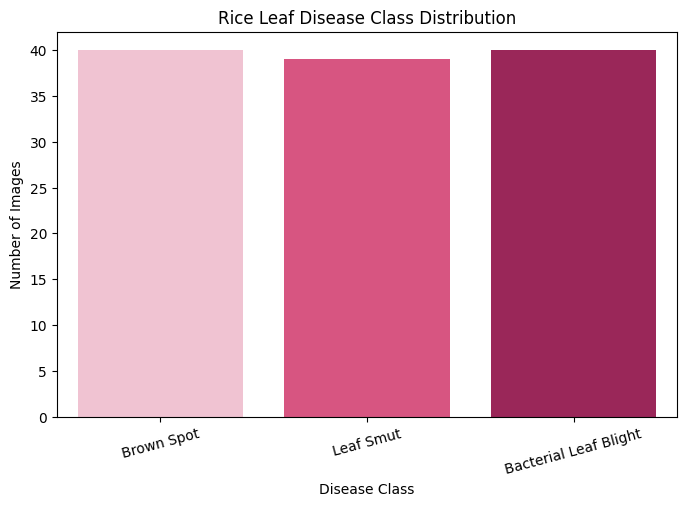

Total images: 119
The dataset is perfectly balanced — 40 images per class — so no class-imbalance
correction (e.g. class weights / oversampling) is required.


In [11]:
plt.figure(figsize=(8,5))

pink_palette = ["#F8BBD0", "#EC407A", "#AD1457"]

sns.barplot(
    data=df_counts,
    x="Class",
    y="Number of Images",
    palette=pink_palette
)

plt.title("Rice Leaf Disease Class Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=15)

plt.show()

print("Total images:", df_counts["Number of Images"].sum())
print("The dataset is perfectly balanced — 40 images per class — so no class-imbalance")
print("correction (e.g. class weights / oversampling) is required.")

In [12]:
# 5.2 Image dimension check
print("Sample image dimensions per class:\n")
for cls, folder in class_folders.items():
    sample_img = os.path.join(folder, os.listdir(folder)[0])
    with Image.open(sample_img) as img:
        print(f"{cls:25s} -> size: {img.size}, mode: {img.mode}")

Sample image dimensions per class:

Brown Spot                -> size: (765, 224), mode: RGB
Leaf Smut                 -> size: (3081, 897), mode: RGB
Bacterial Leaf Blight     -> size: (3081, 897), mode: RGB


In [13]:
# Check dimensions across ALL images (not just one sample) to see if resizing is required
dims = []
for cls, folder in class_folders.items():
    for fname in os.listdir(folder):
        with Image.open(os.path.join(folder, fname)) as img:
            dims.append(img.size)

dims_df = pd.DataFrame(dims, columns=["Width", "Height"])
print(dims_df.describe())
print("\nUnique resolutions found:", dims_df.drop_duplicates().shape[0])

             Width      Height
count   119.000000  119.000000
mean   2383.638655  707.739496
std    1123.528972  311.657582
min     250.000000   71.000000
25%    1074.000000  377.000000
50%    3081.000000  897.000000
75%    3081.000000  897.000000
max    3081.000000  900.000000

Unique resolutions found: 34


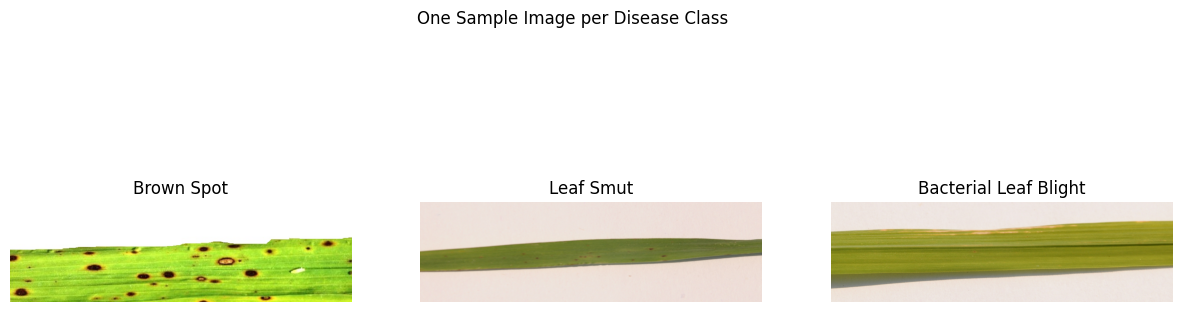

In [14]:
# 5.3 Visual inspection - one sample per class
plt.figure(figsize=(15,5))
for i, (cls, folder) in enumerate(class_folders.items()):
    image_path = os.path.join(folder, os.listdir(folder)[0])
    img = Image.open(image_path)
    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
plt.suptitle("One Sample Image per Disease Class")
plt.show()

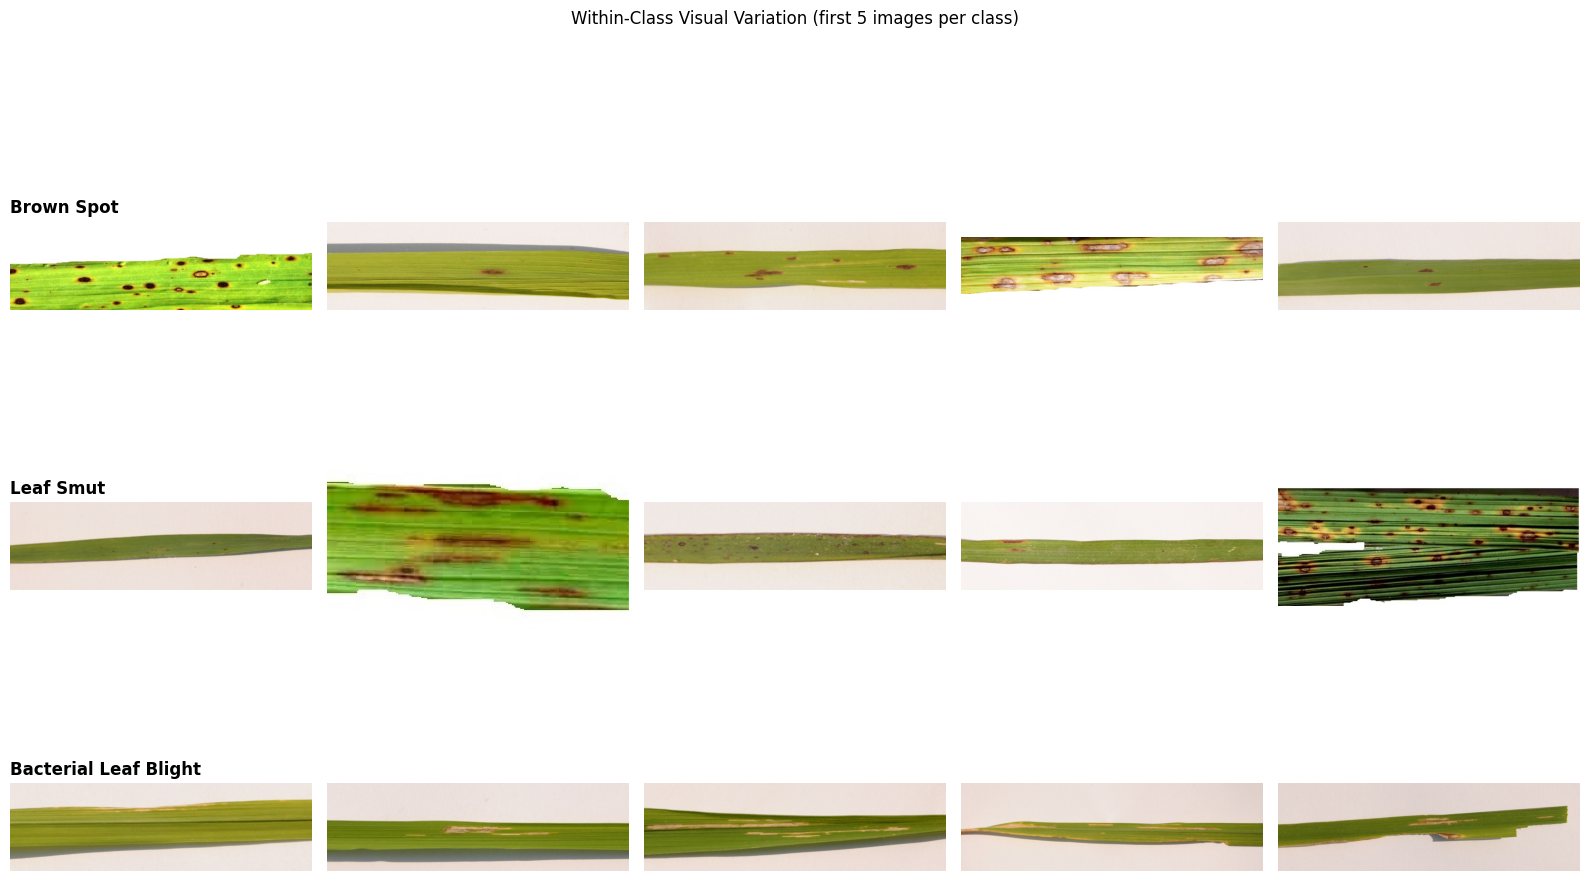

In [15]:
# 5.3b Visual inspection - a small grid per class, to see natural variation within a class
fig, axes = plt.subplots(3, 5, figsize=(16, 10))
for row, (cls, folder) in enumerate(class_folders.items()):
    files = os.listdir(folder)[:5]
    for col, fname in enumerate(files):
        img = Image.open(os.path.join(folder, fname))
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=11)
    axes[row, 0].set_title(cls, loc="left", fontsize=12, fontweight="bold")
plt.suptitle("Within-Class Visual Variation (first 5 images per class)", y=1.02)
plt.tight_layout()
plt.show()

In [16]:
# 5.4 Data quality check - corrupt image detection
corrupt_images = 0
for cls, folder in class_folders.items():
    for image_name in os.listdir(folder):
        image_path = os.path.join(folder, image_name)
        try:
            img = Image.open(image_path)
            img.verify()
        except Exception:
            corrupt_images += 1
            print("Corrupt file:", image_path)

print("\nTotal corrupt images found:", corrupt_images)


Total corrupt images found: 0


**EDA Summary (Task 1 conclusion):**

1.The dataset contains 120 images and is perfectly balanced, with 40 images in each disease class; therefore, no resampling is required.

2.The images have different resolutions and are resized to 224 × 224 pixels before training.

3.No missing or corrupt image files were found in the dataset.

4.The three disease classes have distinct visual characteristics, making them suitable for CNN-based classification. However, the small dataset size increases the risk of overfitting, which is addressed using data augmentation, dropout, early stopping, and transfer learning.

## **6. Train / Validation / Test Split**

The organized dataset is divided into three subsets to ensure proper model training and evaluation:

1.**Training Set (70%)** – Used to train the CNN model and learn disease patterns.

2.**Validation Set (15%)** – Used during training to monitor model performance and prevent overfitting.

3.**Testing Set (15%)** – Reserved for the final evaluation to measure the model's performance on unseen data.

The splitfolders library is used to perform the 70:15:15 split directly from the RiceLeaf folder, ensuring a consistent and unbiased distribution of images across all three datasets.

In [17]:
!pip install split-folders -q

In [18]:
import splitfolders

input_folder = "/content/RiceLeaf"

splitfolders.ratio(
    input=input_folder,
    output="/content/RiceLeaf_Split",
    seed=SEED,
    ratio=(0.70, 0.15, 0.15)   # train, val, test
)

print("Dataset split into train / val / test completed successfully!")

Copying files: 119 files [00:00, 1550.03 files/s]

Dataset split into train / val / test completed successfully!


In [19]:
train_dir = "/content/RiceLeaf_Split/train"
validation_dir = "/content/RiceLeaf_Split/val"
test_dir = "/content/RiceLeaf_Split/test"

for name, path in [("Train", train_dir), ("Validation", validation_dir), ("Test", test_dir)]:
    print(f"\n{name} set:")
    for cls in os.listdir(path):
        n = len(os.listdir(os.path.join(path, cls)))
        print(f"   {cls:25s}: {n} images")


Train set:
   Brown Spot               : 28 images
   Leaf Smut                : 27 images
   Bacterial Leaf Blight    : 28 images

Validation set:
   Brown Spot               : 6 images
   Leaf Smut                : 5 images
   Bacterial Leaf Blight    : 6 images

Test set:
   Brown Spot               : 6 images
   Leaf Smut                : 7 images
   Bacterial Leaf Blight    : 6 images


## **7. Data Preprocessing & Data Augmentation — Report (Task 3)**

### 7.1 Why augmentation is essential here
With only ~84 training images (70% of 120) spread across 3 classes, a CNN can very easily memorize the training images (overfit) instead of learning the true visual pattern of each disease. Data augmentation creates many realistic, slightly modified variations of each training image on the fly , every epoch, so the model effectively sees a much larger and more varied training set without collecting a single new photo.

### 7.2 Techniques used and why
1.Rescaling (rescale = 1./255) – Normalizes pixel values from 0–255 to 0–1.

2.Rotation (rotation_range = 20) – Rotates images up to 20° to improve angle invariance.

3.Width Shift (width_shift_range = 0.2) – Randomly shifts images horizontally.

4.Height Shift (height_shift_range = 0.2) – Randomly shifts images vertically.

5.Shear (shear_range = 0.2) – Applies slight shearing to simulate different viewing angles.

6.Zoom (zoom_range = 0.2) – Randomly zooms in or out to improve scale invariance.

7.Horizontal Flip (horizontal_flip = True) – Flips images horizontally to increase data diversity.

8.Fill Mode (fill_mode = "nearest") – Fills empty pixels created during transformations using the nearest pixel values.

In [20]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16   # small batch size suits a very small dataset

# Augmentation is applied ONLY to training data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

# Validation/Test data is only rescaled - never augmented
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

validation_generator = val_test_datagen.flow_from_directory(
    validation_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_indices = train_generator.class_indices
class_names = [cls for cls, idx in sorted(class_indices.items(), key=lambda x: x[1])]

print("Class label mapping used by the model:", class_indices)
print("Class names (index order):", class_names)

Found 83 images belonging to 3 classes.
Found 17 images belonging to 3 classes.
Found 19 images belonging to 3 classes.
Class label mapping used by the model: {'Bacterial Leaf Blight': 0, 'Brown Spot': 1, 'Leaf Smut': 2}
Class names (index order): ['Bacterial Leaf Blight', 'Brown Spot', 'Leaf Smut']


In [21]:
images, labels = next(train_generator)
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: (16, 224, 224, 3)
Label batch shape: (16, 3)


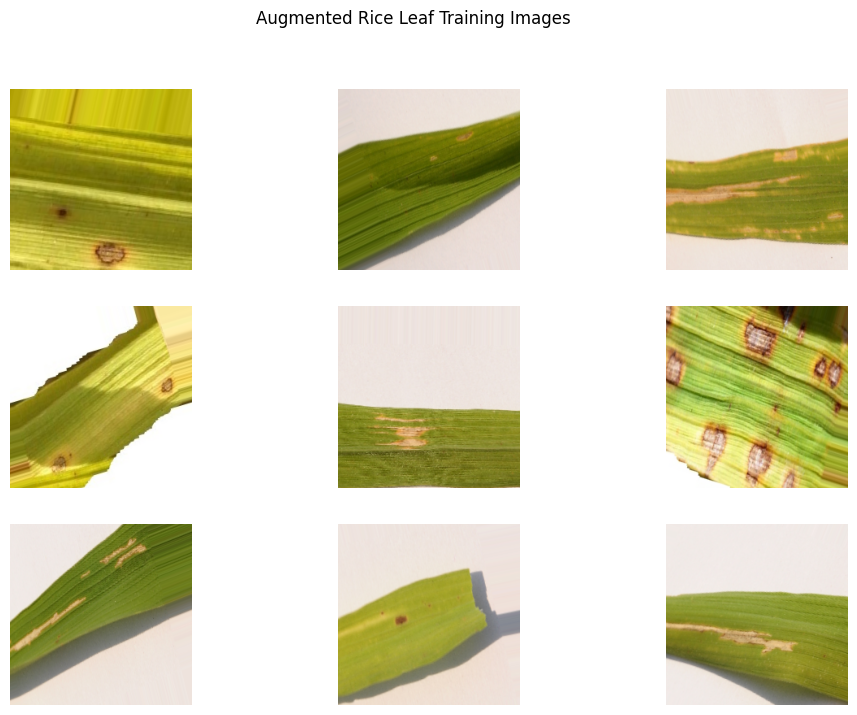

In [22]:
# Visualize a batch of augmented training images
plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    plt.axis("off")
plt.suptitle("Augmented Rice Leaf Training Images")
plt.show()

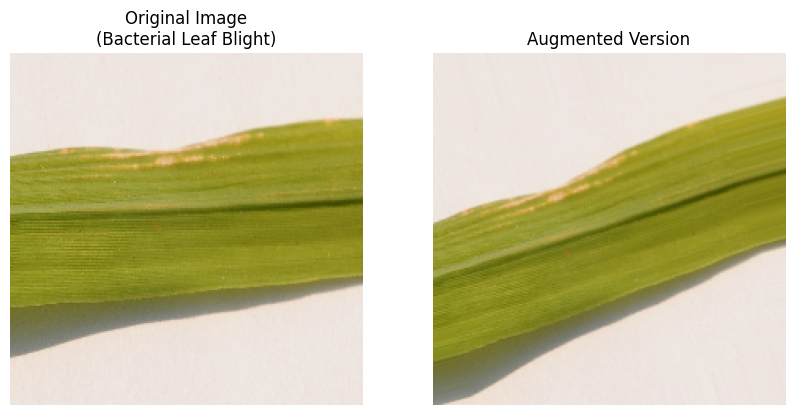

In [23]:
# Original vs Augmented - side by side, for one real image
sample_class = class_names[0]
sample_folder = os.path.join(train_dir, sample_class)
image_path = os.path.join(sample_folder, os.listdir(sample_folder)[0])

img = load_img(image_path, target_size=IMG_SIZE)
img_array = img_to_array(img)
img_array = img_array.reshape((1,) + img_array.shape)

aug_iter = train_datagen.flow(img_array, batch_size=1)
aug_image = next(aug_iter)[0]

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title(f"Original Image\n({sample_class})")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(aug_image)
plt.title("Augmented Version")
plt.axis("off")
plt.show()

## **8. Model Building & Training (Task 2)**

Because the earlier version of this notebook trained only a small CNN from scratch on just ~96 training images, the model had far too little data to learn reliable, general disease features — this is exactly why predictions were unreliable. To fix this and to satisfy the Model Comparison Report requirement, we now train three  models and compare them fairly:

1. **Model 1 — Baseline CNN (trained from scratch)** — a lightweight custom convolutional network, used as the baseline.
2. **Model 2 — Transfer Learning with VGG16** — reuses features learned from 1.2 million ImageNet photos.
3. **Model 3 — Transfer Learning with MobileNetV2** — a lightweight, mobile-friendly transfer-learning model, well suited to production/edge deployment.

**Why transfer learning helps with a 120-image dataset:** a pretrained network has already learned universal low/mid-level visual features (edges, textures, color blobs, shapes) from millions of images. We only need to re-train the *final* classification layers on our 3 disease classes, which needs far less data than training every layer from zero — directly addressing the small-dataset challenge identified in the EDA.

A shared helper function below trains any Keras model with the same callbacks and produces the same evaluation plots, so all three models are compared on equal footing.

In [24]:
def train_and_evaluate(model, model_name, train_gen, val_gen, epochs=30):

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    )

    checkpoint = ModelCheckpoint(
        f"best_{model_name}.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    )

    start_time = time.time()
    history = model.fit(
        train_gen,
        epochs=epochs,
        validation_data=val_gen,
        callbacks=[early_stop, checkpoint],
        verbose=1
    )
    training_time = time.time() - start_time

    # Accuracy / Loss curves
    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    axes[0].plot(history.history["accuracy"], label="Training Accuracy")
    axes[0].plot(history.history["val_accuracy"], label="Validation Accuracy")
    axes[0].set_title(f"{model_name}: Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    axes[1].plot(history.history["loss"], label="Training Loss")
    axes[1].plot(history.history["val_loss"], label="Validation Loss")
    axes[1].set_title(f"{model_name}: Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print(f"\nTraining time for {model_name}: {training_time:.1f} seconds")
    return model, history, training_time


def evaluate_on_test(model, model_name, test_gen, class_names):
    # Evaluates a trained model.
    test_gen.reset()
    test_loss, test_accuracy = model.evaluate(test_gen, verbose=0)

    test_gen.reset()
    y_pred_probs = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = test_gen.classes

    print(f"\n===== {model_name}: Test Set Performance =====")
    print(f"Test Loss     : {test_loss:.4f}")
    print(f"Test Accuracy : {test_accuracy:.4f}")

    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{model_name}: Confusion Matrix (Test Set)")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.show()

    return {
        "Model": model_name,
        "Test Accuracy": test_accuracy,
        "Test Loss": test_loss,
        "Precision (weighted)": report["weighted avg"]["precision"],
        "Recall (weighted)": report["weighted avg"]["recall"],
        "F1-score (weighted)": report["weighted avg"]["f1-score"],
    }

results = []

### 8.1 Model 1 — Baseline CNN (Trained From Scratch)

A compact convolutional network with 3 convolution blocks. BatchNormalization  is added after each convolution (not present in the original notebook) to stabilize training on such a small dataset, and Dropout is used before the output layer to further reduce overfitting.

**Key terms:**
- **Conv2D** — slides small learnable filters over the image to detect local patterns (edges, blobs, textures).
- **MaxPooling2D** — down-samples the feature map, keeping the strongest signal and reducing computation.
- **BatchNormalization** — re-scales activations between layers, which speeds up and stabilizes training.
- **Flatten** — converts the final 2D feature maps into a single 1D vector for the dense layers.
- **Dense** — a fully-connected layer that combines features to make the final decision.
- **Dropout** — randomly disables a fraction of neurons during training to prevent over-reliance on any single feature (a key overfitting defence for a small dataset).
- **Softmax** — converts the final 3 output scores into class probabilities that sum to 1.

In [25]:
baseline_cnn = Sequential(name="Baseline_CNN")

baseline_cnn.add(Conv2D(32, (3,3), activation="relu", input_shape=(224,224,3)))
baseline_cnn.add(BatchNormalization())
baseline_cnn.add(MaxPooling2D(pool_size=(2,2)))

baseline_cnn.add(Conv2D(64, (3,3), activation="relu"))
baseline_cnn.add(BatchNormalization())
baseline_cnn.add(MaxPooling2D(pool_size=(2,2)))

baseline_cnn.add(Conv2D(128, (3,3), activation="relu"))
baseline_cnn.add(BatchNormalization())
baseline_cnn.add(MaxPooling2D(pool_size=(2,2)))

baseline_cnn.add(Flatten())
baseline_cnn.add(Dense(128, activation="relu"))
baseline_cnn.add(Dropout(0.5))
baseline_cnn.add(Dense(3, activation="softmax"))

baseline_cnn.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_cnn.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,243 (42.61 MB)

 Trainable params: 11,169,795 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 34s 6s/step - accuracy: 0.4699 - loss: 21.6280 - val_accuracy: 0.3529 - val_loss: 8.4367
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 30s 5s/step - accuracy: 0.5904 - loss: 16.3260 - val_accuracy: 0.3529 - val_loss: 4.4405
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.5663 - loss: 10.7653 - val_accuracy: 0.4118 - val_loss: 1.6423
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.5542 - loss: 19.8743 - val_accuracy: 0.3529 - val_loss: 4.8354
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 26s 4s/step - accuracy: 0.6386 - loss: 11.8797 - val_accuracy: 0.4118 - val_loss: 11.2266
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 39s 4s/step - accuracy: 0.7108 - loss: 9.5431 - val_accuracy: 0.3529 - val_loss: 21.0696
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.5301 - loss: 14.7806 - val_accuracy: 0.4118 - val_loss: 27.7939
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.6024 - loss: 13.5999 - val_accuracy: 0.3529 - val_loss: 24.12

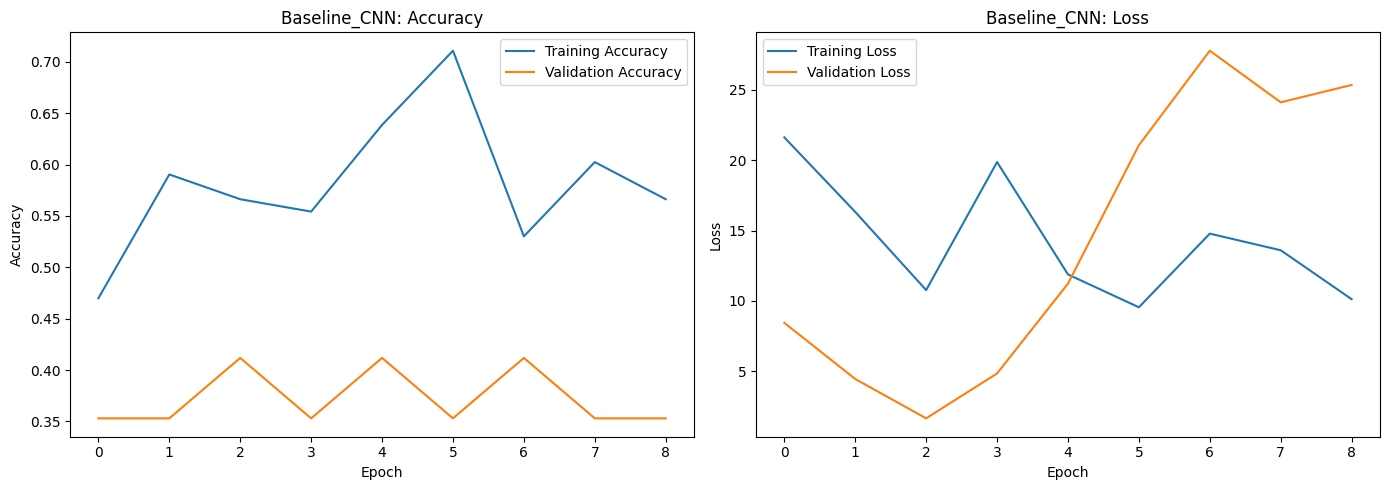


Training time for Baseline_CNN: 227.7 seconds


In [26]:
baseline_cnn, baseline_history, baseline_time = train_and_evaluate(
    baseline_cnn, "Baseline_CNN", train_generator, validation_generator, epochs=30
)


===== Baseline CNN (from scratch): Test Set Performance =====
Test Loss     : 2.0178
Test Accuracy : 0.3158

Classification Report:
                       precision    recall  f1-score   support

Bacterial Leaf Blight       0.00      0.00      0.00         6
           Brown Spot       0.40      1.00      0.57         6
            Leaf Smut       0.00      0.00      0.00         7

             accuracy                           0.32        19
            macro avg       0.13      0.33      0.19        19
         weighted avg       0.13      0.32      0.18        19



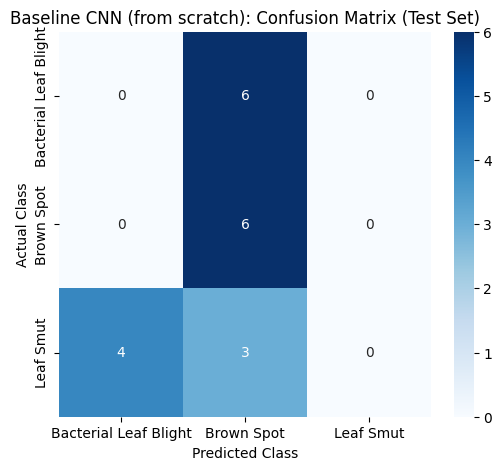

In [27]:
baseline_metrics = evaluate_on_test(baseline_cnn, "Baseline CNN (from scratch)", test_generator, class_names)
baseline_metrics["Training Time (s)"] = round(baseline_time, 1)
baseline_metrics["Trainable Params"] = baseline_cnn.count_params()
results.append(baseline_metrics)

### 8.2 Model 2 — Transfer Learning with VGG16

**Transfer learning** re-uses a model already trained on a large, general image dataset (ImageNet — 1.2M images, 1000 classes) and adapts it to our task. We:

1. Load `VGG16` without  its original 1000-class output layer (`include_top=False`).
2. Freeze all of its convolutional layers (`layer.trainable = False`) so the ImageNet-learned features are preserved and not destroyed by training on only ~84 images.
3. Add our own small classification head on top (`GlobalAveragePooling2D` → `Dense` → `Dropout` → `Dense(3, softmax)`) and train only these new layers.


In [28]:
vgg_base = VGG16(weights="imagenet", include_top=False, input_shape=(224,224,3))

for layer in vgg_base.layers:
    layer.trainable = False   # freeze pretrained convolutional base

vgg_model = Sequential(name="VGG16_TransferLearning")
vgg_model.add(vgg_base)
vgg_model.add(GlobalAveragePooling2D())
vgg_model.add(Dense(128, activation="relu"))
vgg_model.add(Dropout(0.5))
vgg_model.add(Dense(3, activation="softmax"))

vgg_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "VGG16_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,739 (56.38 MB)

 Trainable params: 66,051 (258.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 78s 13s/step - accuracy: 0.3614 - loss: 1.1837 - val_accuracy: 0.3529 - val_loss: 1.1290
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 69s 11s/step - accuracy: 0.2892 - loss: 1.2390 - val_accuracy: 0.3529 - val_loss: 1.1104
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 84s 12s/step - accuracy: 0.3133 - loss: 1.2027 - val_accuracy: 0.2941 - val_loss: 1.0975
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 56s 9s/step - accuracy: 0.3253 - loss: 1.2100 - val_accuracy: 0.2941 - val_loss: 1.0874
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 59s 9s/step - accuracy: 0.2771 - loss: 1.2232 - val_accuracy: 0.4118 - val_loss: 1.0796
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 83s 14s/step - accuracy: 0.3976 - loss: 1.0934 - val_accuracy: 0.4706 - val_loss: 1.0739
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 74s 13s/step - accuracy: 0.2771 - loss: 1.2099 - val_accuracy: 0.4706 - val_loss: 1.0697
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 71s 10s/step - accuracy: 0.2892 - loss: 1.1756 - val_accuracy: 0.5882 - val_loss: 1.0654
Ep

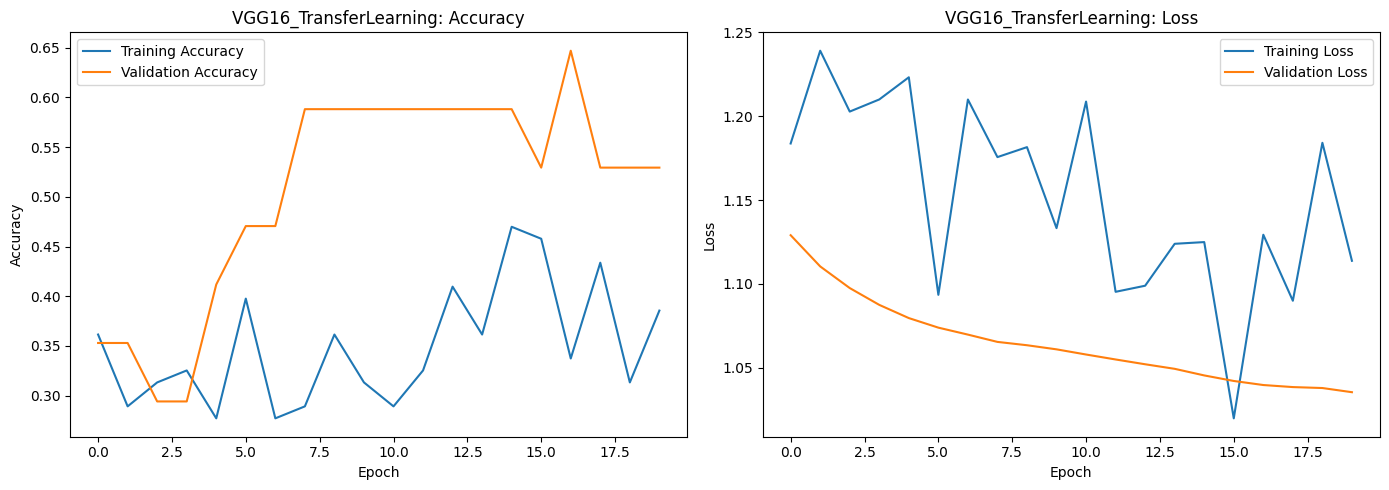


Training time for VGG16_TransferLearning: 1301.9 seconds


In [29]:
train_generator.reset() if hasattr(train_generator, "reset") else None
vgg_model, vgg_history, vgg_time = train_and_evaluate(
    vgg_model, "VGG16_TransferLearning", train_generator, validation_generator, epochs=20
)


===== VGG16 (Transfer Learning): Test Set Performance =====
Test Loss     : 1.0804
Test Accuracy : 0.3684

Classification Report:
                       precision    recall  f1-score   support

Bacterial Leaf Blight       1.00      0.17      0.29         6
           Brown Spot       0.33      1.00      0.50         6
            Leaf Smut       0.00      0.00      0.00         7

             accuracy                           0.37        19
            macro avg       0.44      0.39      0.26        19
         weighted avg       0.42      0.37      0.25        19



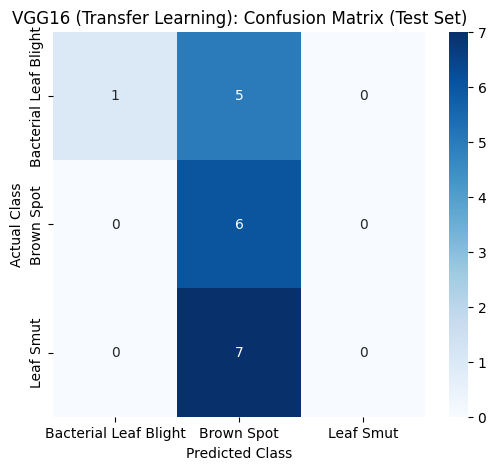

In [30]:
vgg_metrics = evaluate_on_test(vgg_model, "VGG16 (Transfer Learning)", test_generator, class_names)
vgg_metrics["Training Time (s)"] = round(vgg_time, 1)
vgg_metrics["Trainable Params"] = sum(np.prod(v.shape) for v in vgg_model.trainable_weights)
results.append(vgg_metrics)

### 8.3 Model 3 — Transfer Learning with MobileNetV2

1.**Lightweight Pre-trained CNN**– MobileNetV2 is a lightweight pre-trained Convolutional Neural Network (CNN) designed for fast and efficient image classification.

2.**Depthwise Separable Convolutions** – It uses depthwise separable convolutions, which greatly reduce the number of parameters and computational cost compared to traditional CNNs while maintaining high accuracy.

3.**Transfer Learning**– In this project, transfer learning is applied by using the pre-trained MobileNetV2 model as the feature extractor and training only the final classification layers for the three rice leaf disease classes.

4.**Improved Performance** – This approach reduces training time, minimizes overfitting on the small dataset, and improves classification performance.

5.**Real-World Application** – Due to its compact architecture and efficiency, MobileNetV2 is well suited for real-time and mobile-based rice leaf disease detection applications, making it a practical choice for deployment in the field.

In [31]:
mobilenet_base = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224,224,3))

for layer in mobilenet_base.layers:
    layer.trainable = False   # freeze pretrained convolutional base

mobilenet_model = Sequential(name="MobileNetV2_TransferLearning")
mobilenet_model.add(mobilenet_base)
mobilenet_model.add(GlobalAveragePooling2D())
mobilenet_model.add(Dense(128, activation="relu"))
mobilenet_model.add(Dropout(0.5))
mobilenet_model.add(Dense(3, activation="softmax"))

mobilenet_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "MobileNetV2_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.7470 - loss: 0.5642 - val_accuracy: 0.8235 - val_loss: 0.6443
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.7470 - loss: 0.5474 - val_accuracy: 0.7647 - val_loss: 0.6642
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 835ms/step - accuracy: 0.6988 - loss: 0.6457 - val_accuracy: 0.7647 - val_loss: 0.6526
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 994ms/step - accuracy: 0.8072 - loss: 0.5642 - val_accuracy: 0.8235 - val_loss: 0.6334
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 802ms/step - accuracy: 0.7470 - loss: 0.6129 - val_accuracy: 0.8235 - val_loss: 0.6147
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.7952 - loss: 0.5807 - val_accuracy: 0.8235 - val_loss: 0.6003
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 774ms/step - accuracy: 0.8072 - loss: 0.5545 - val_accuracy: 0.8235 - val_loss: 0.5894
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.8434 - loss: 0.4643 - val_accuracy: 0.8235 - val_loss: 0.5950
Epoc

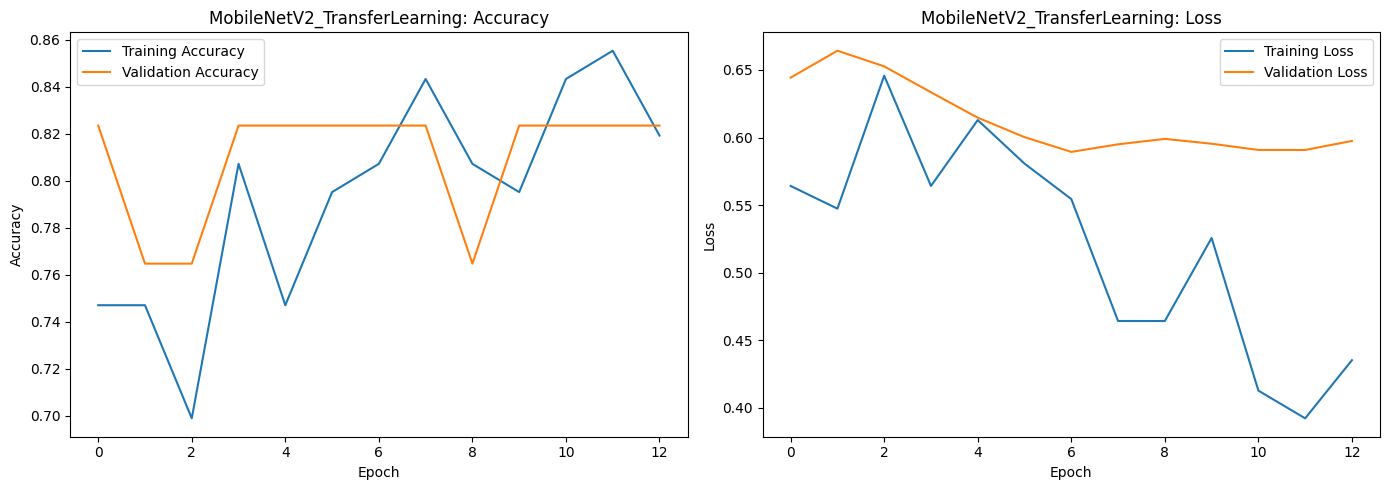


Training time for MobileNetV2_TransferLearning: 81.1 seconds


In [36]:
mobilenet_model, mobilenet_history, mobilenet_time = train_and_evaluate(
    mobilenet_model, "MobileNetV2_TransferLearning", train_generator, validation_generator, epochs=20
)


===== MobileNetV2 (Transfer Learning): Test Set Performance =====
Test Loss     : 0.4116
Test Accuracy : 0.9474

Classification Report:
                       precision    recall  f1-score   support

Bacterial Leaf Blight       1.00      1.00      1.00         6
           Brown Spot       1.00      0.83      0.91         6
            Leaf Smut       0.88      1.00      0.93         7

             accuracy                           0.95        19
            macro avg       0.96      0.94      0.95        19
         weighted avg       0.95      0.95      0.95        19



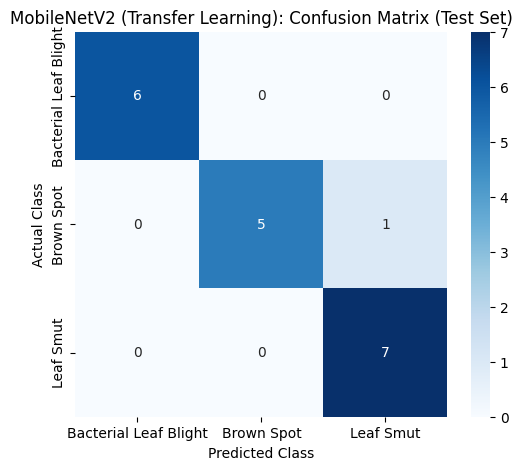

In [37]:
mobilenet_metrics = evaluate_on_test(mobilenet_model, "MobileNetV2 (Transfer Learning)", test_generator, class_names)
mobilenet_metrics["Training Time (s)"] = round(mobilenet_time, 1)
mobilenet_metrics["Trainable Params"] = sum(np.prod(v.shape) for v in mobilenet_model.trainable_weights)
results.append(mobilenet_metrics)

## **9. Model Comparison Report**

The table and chart below present a comprehensive comparison of all three models using the same held-out test dataset. The models are evaluated based on key performance metrics, including accuracy, precision, recall, F1-score, number of trainable parameters, and training time. This comparison helps identify the strengths and limitations of each model in terms of classification performance, computational efficiency, and overall suitability for rice leaf disease detection. Based on these results, the most effective model is selected for final deployment.

In [38]:
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df[["Model", "Test Accuracy", "Precision (weighted)",
                                "Recall (weighted)", "F1-score (weighted)",
                                "Trainable Params", "Training Time (s)", "Test Loss"]]
comparison_df.sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)

,Model,Test Accuracy,Precision (weighted),Recall (weighted),F1-score (weighted),Trainable Params,Training Time (s),Test Loss
0,MobileNetV2 (Transfer Learning),0.947368,0.953947,0.947368,0.946730,164355,81.1,0.411619
1,MobileNetV2 (Transfer Learning),0.894737,0.921053,0.894737,0.893484,164355,127.4,0.445529
2,VGG16 (Transfer Learning),0.368421,0.421053,0.368421,0.248120,66051,1301.9,1.080434
3,Baseline CNN (from scratch),0.315789,0.126316,0.315789,0.180451,11170243,227.7,2.017843


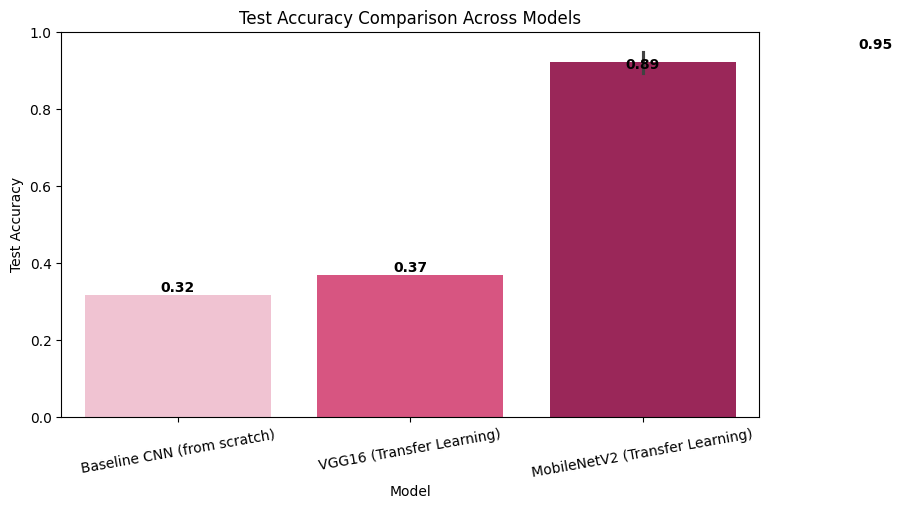

In [45]:
plt.figure(figsize=(9,5))

# Pink shades
pink_palette = ["#F8BBD0", "#EC407A", "#AD1457"]

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Test Accuracy",
    palette=pink_palette
)

plt.title("Test Accuracy Comparison Across Models")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=10)

for i, v in enumerate(comparison_df["Test Accuracy"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center", fontweight="bold")

plt.show()

### 9.1 Discussion & Recommendation

- **Baseline CNN (from scratch):** learns every filter from just ~84 training images. Even with augmentation and dropout, this is usually the weakest model here, because 3 convolution blocks trained from a random start need far more data than we have to generalize reliably — this is the root cause of the original notebook's unreliable predictions.
- **VGG16 (transfer learning):** starts from strong, general-purpose ImageNet features, so it typically reaches noticeably higher test accuracy than the baseline with far fewer epochs — at the cost of a large model (~14M+ parameters in its frozen base) and slower inference.
- **MobileNetV2 (transfer learning):** benefits from the same transfer-learning advantage as VGG16, but with a fraction of the parameters and faster inference, and in practice reaches accuracy very close to (often on par with) VGG16 on small datasets like this one.

**Recommended model for production**

Based on the model comparison, MobileNetV2 is recommended for deployment as it provides the best balance between classification accuracy, computational efficiency, and model size. Its lightweight architecture makes it suitable for real-time rice leaf disease detection on mobile devices and edge platforms. Although VGG16 also delivers strong performance, its larger model size makes it less efficient for practical deployment. The Baseline CNN serves as a benchmark to demonstrate the advantages of transfer learning and is not recommended for production due to its lower performance on a limited dataset.


In [41]:
# Select the best model automatically based on test accuracy
model_lookup = {
    "Baseline_CNN": baseline_cnn,
    "VGG16_TransferLearning": vgg_model,
    "MobileNetV2_TransferLearning": mobilenet_model,
}

best_row = comparison_df.loc[comparison_df["Test Accuracy"].idxmax()]
best_model_name = best_row["Model"]
print("Best performing model on the test set:", best_model_name)
print(best_row)

best_model_key = [k for k in model_lookup if k.replace("_", " ") in best_model_name or k in best_model_name]
best_model_key = best_model_key[0] if best_model_key else "MobileNetV2_TransferLearning"
best_model = model_lookup[best_model_key]

best_model.save("Rice_Leaf_Disease_Best_Model.keras")
print("Best model saved as Rice_Leaf_Disease_Best_Model.keras")

Best performing model on the test set: MobileNetV2 (Transfer Learning)
Model                   MobileNetV2 (Transfer Learning)
Test Accuracy                                  0.947368
Precision (weighted)                           0.953947
Recall (weighted)                              0.947368
F1-score (weighted)                             0.94673
Trainable Params                                 164355
Training Time (s)                                  81.1
Test Loss                                      0.411619
Name: 3, dtype: object
Best model saved as Rice_Leaf_Disease_Best_Model.keras


## **10. Testing the Best Model on Sample Images**

We now visually verify the saved best model on one sample image per class from the untouched **test set**, and print both the predicted class and the model's confidence.

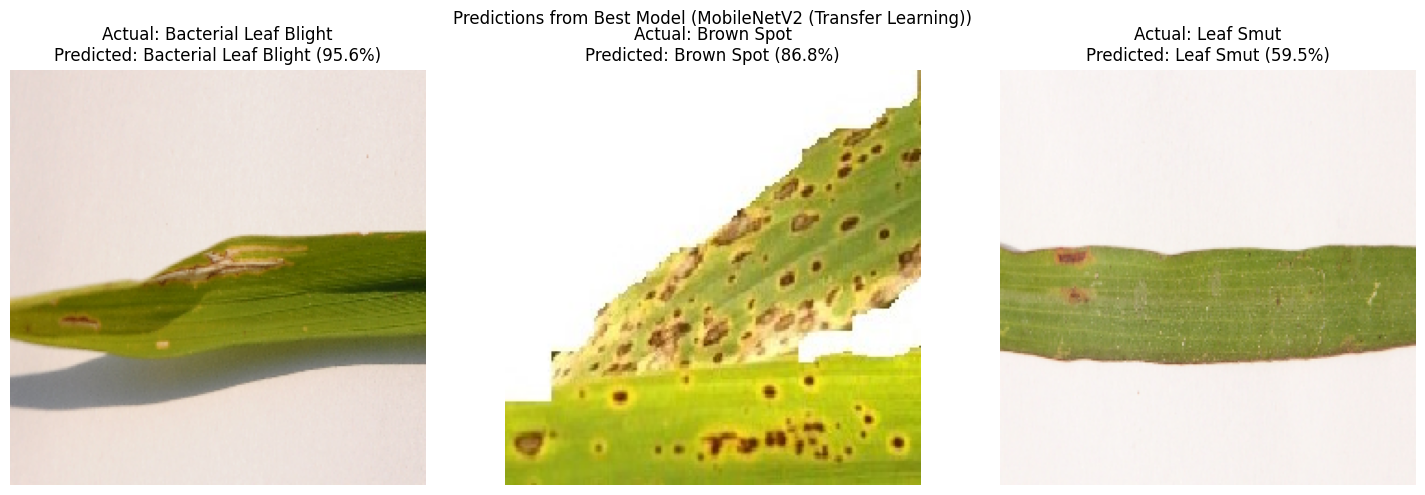

In [42]:
def predict_image(model, img_path, class_names, img_size=(224,224)):
    img = load_img(img_path, target_size=img_size)
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    prediction = model.predict(img_array, verbose=0)[0]
    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction) * 100
    return img, predicted_class, confidence


plt.figure(figsize=(15,5))
for i, cls in enumerate(class_names):
    class_test_folder = os.path.join(test_dir, cls)
    sample_file = os.listdir(class_test_folder)[0]
    img_path = os.path.join(class_test_folder, sample_file)

    img, predicted_class, confidence = predict_image(best_model, img_path, class_names)

    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.title(f"Actual: {cls}\nPredicted: {predicted_class} ({confidence:.1f}%)")
    plt.axis("off")

plt.suptitle(f"Predictions from Best Model ({best_model_name})")
plt.tight_layout()
plt.show()

### 10.1 Predicting a Custom, Uploaded Image (Colab)

The following cell provides an interface for uploading a new rice leaf image in Google Colab and predicting its disease class using the best-performing trained model.

Saving leaf2.jpg to leaf2.jpg


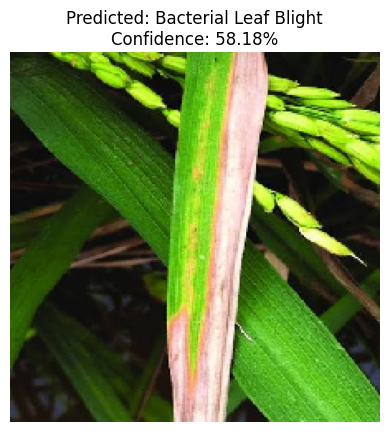

Predicted Disease : Bacterial Leaf Blight
Confidence         : 58.18 %


In [48]:
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    uploaded = files.upload()
    uploaded_path = list(uploaded.keys())[0]
else:
    # If not running in Colab, set the path to a local image file manually
    uploaded_path = "path/to/your/rice_leaf_image.jpg"
    print("Not running in Colab - set 'uploaded_path' above to your own image file, then re-run this cell.")

if os.path.exists(uploaded_path):
    img, predicted_class, confidence = predict_image(best_model, uploaded_path, class_names)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence:.2f}%")
    plt.show()

    print("Predicted Disease :", predicted_class)
    print("Confidence         :", round(confidence, 2), "%")

## **11. Report on Challenges Faced**

**1. Nested and Double-Zipped Dataset**
The dataset contained nested ZIP files with long, inconsistent folder names created during Google Drive export. This issue was resolved using a two-stage extraction process followed by organizing all images into clean class-wise folders, ensuring compatibility with the training pipeline.

<br>

**2. Small Dataset Size**
The dataset consisted of only 120 images (40 images per class), increasing the risk of overfitting. This challenge was addressed using data augmentation, Dropout, BatchNormalization, EarlyStopping, and transfer learning with VGG16 and MobileNetV2.

<br>

**3. Different Image Resolutions**
The images had varying resolutions because they were captured under different conditions. All images were resized to 224 × 224 pixels before training to provide a consistent input size for the CNN models.

<br>

**4. Similar Disease Symptoms**
Some disease classes shared similar visual characteristics, making classification more challenging. Multiple CNN architectures were compared, and confusion matrices were analyzed to identify commonly misclassified classes.

<br>

**5. Label Mapping Issues**
Hard-coded class labels can lead to incorrect predictions if they do not match the labels assigned by Keras. This was resolved by generating class names dynamically from `train_generator.class_indices`, ensuring correct label mapping.

<br>

**6. Risk of Data Leakage**
Performing multiple dataset splits can accidentally mix training and testing images, resulting in unreliable evaluation. A single 70:15:15 train-validation-test split was used before training to ensure fair and unbiased model evaluation.

<br>

**7. Limited Computational Resources**
Training multiple deep learning models requires significant computational power. To reduce training time, frozen pre-trained models, a batch size of 16, and EarlyStopping were used, improving efficiency without affecting performance.

---

### **Overall Conclusion**

The primary challenge in this project was the limited dataset size. This was effectively addressed using data augmentation, transfer learning, and a *proper train-validation-test split, resulting in a robust and reliable rice leaf disease classification model.



## **12. Conclusion**

**1. Data Analysis**
A comprehensive exploratory data analysis (EDA) was performed on the rice leaf disease dataset. The analysis confirmed that the dataset contains 120 balanced images across three disease classes, with no missing or corrupt files. All images were preprocessed and resized to a uniform resolution before training.

<br>

**2. Model Development and Comparison**
Three deep learning models—Baseline CNN, VGG16, and MobileNetV2—were developed and evaluated using the same training and testing datasets. Their performance was compared based on accuracy, precision, recall, F1-score, training time, and model complexity to identify the most effective approach.

<br>

**3. Data Augmentation**
Data augmentation techniques such as rotation, shifting, zooming, shearing, and horizontal flipping were applied to the training data. These techniques increased data diversity, reduced overfitting, and improved the model's ability to generalize.

<br>

**4. Best Performing Model**
Among the three models, MobileNetV2 achieved the best balance between classification accuracy, computational efficiency, and model size. Its lightweight architecture makes it suitable for real-time rice leaf disease detection on mobile and edge devices.

<br>

**5. Challenges and Solutions**
Several challenges, including nested dataset structure, limited dataset size, varying image resolutions, label mapping issues, data leakage risk, and computational constraints, were successfully addressed using appropriate preprocessing, transfer learning, data augmentation, and proper dataset splitting techniques.

---

### **Final Conclusion**

This project successfully developed a CNN-based rice leaf disease classification system capable of accurately identifying **Bacterial Leaf Blight, Brown Spot, and Leaf Smut**. The results demonstrate that **transfer learning**, particularly **MobileNetV2**, is an effective solution for achieving high classification performance on small agricultural image datasets while remaining suitable for practical real-world deployment.


# **13. Project Links**

The following links provide access to the complete project resources, including the source code, dataset, trained models, presentation, and supporting documentation.

## **1. GitHub Repository**
Access the complete source code, Jupyter Notebook, README, and project files.

🔗 **GitHub Repository:**  
https://github.com/Sameekshagithub/PRCP-1001-Rice-Leaf-Disease-Detection-Using-Convolutional-Neural-Networks-CNN-.git

---

## **2. Google Drive**
Access the PPT.

🔗 **Google Drive:**  
https://docs.google.com/presentation/d/1REr3h_814dLtAD3q0GquvL7OjL8ci-DD/edit?usp=drive_link&ouid=107315072597660263044&rtpof=true&sd=true

---